In [1]:
# import libraries, 
# tensorflow: deep learning machine
# keras: tools to build neural network layer by layer
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# downloads and splits the dataset automatically
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

In [3]:
#confirmed the count of train data
# since X stores images, thus (num, height, weight, colour(RGB))
X_test.shape

(10000, 32, 32, 3)

In [4]:
X_train.shape

(50000, 32, 32, 3)

In [5]:
# in image classification, y= labels, 
# in this case it shows '1'= only one number for the class
y_train.shape

(50000, 1)

In [6]:
# Shows the first 5 labels in their original 2D format
y_train[:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [7]:
# Converts y_train from 2D shape (50000, 1) to 1D shape (50000,)
y_train = y_train.reshape(-1,) # reshape(-1,) means "flatten to one dimension
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [8]:
y_test = y_test.reshape(-1,)

In [9]:
# Creates a list that maps each number (0-9) to its class name
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [10]:
def plot_sample(X, y, index): # Defines a reusable function to display one image with its label
    plt.figure(figsize=(15,2)) # Creates a blank canvas to draw on
    plt.imshow(X[index])  # imshow() draws that image on the canvas so it is visible
    plt.xlabel(classes[y[index]])

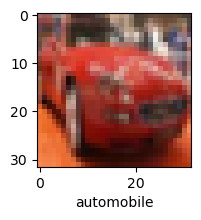

In [11]:
# Calls the function to display image number 5 from training set
plot_sample(X_train, y_train, 5)

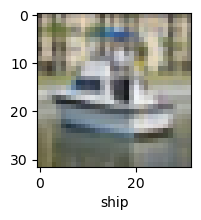

In [12]:
plot_sample(X_train, y_train, 501)

In [13]:
# normalize pixels by dividing them to 0-1
# training more stable
# and help the optimizer converge faster
X_train = X_train / 255.0
X_test = X_test / 255.0

In [14]:
ann = models.Sequential([   # Sequential means layers are stacked one after another in order
    layers.Flatten(input_shape = (32, 32, 3)), # Converts each 3D image (32x32x3) into a 1D array of 3072 numbers
    layers.Dense(3000, activation = 'relu'), # Fully connected layer with 3000 neurons  # Every neuron connects to all 3072 inputs from the flatten layer # activation='relu' keeps positive values as-is, turns negatives to 0 # ReLU helps the model learn complex non-linear patterns
    layers.Dense(1000, activation = 'relu'), # Takes 3000 inputs from previous layer & Continues to refine and compress the learned features
    layers.Dense(10, activation = 'softmax'), # Output layer with exactly 10 neurons — one for each class # activation='softmax' converts raw scores into probabilities
])

ann.compile(optimizer = 'SGD', # The algorithm that updates the model weights after each batch
                               # It calculates how wrong the prediction was and adjusts weights
            loss = 'sparse_categorical_crossentropy', # The formula used to measure how wrong the predictions are
                                                      # 'sparse' means labels are integers (0,1,2...) not one-hot encoded
                                                      # 'categorical_crossentropy' is standard for multi-class classification
            metrics = ['accuracy'])

ann.fit(X_train, y_train, epochs = 5) # Trains the ANN model on training data
                                      # epochs=5 means the model sees all 50,000 images 5 complete times
                                      # Each epoch the model improves by adjusting its weights

C:\Users\Stell\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 92s 57ms/step - accuracy: 0.3537 - loss: 1.8126
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 90s 57ms/step - accuracy: 0.4257 - loss: 1.6224
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.4541 - loss: 1.5438
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 89s 57ms/step - accuracy: 0.4768 - loss: 1.4831
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 90s 58ms/step - accuracy: 0.4970 - loss: 1.4315


In [15]:
from sklearn.metrics import confusion_matrix, classification_report # confusion_matrix   → shows which classes were confused with each other
                                                                    # classification_report → shows precision, recall, F1 for each class
import numpy as np
y_pred = ann.predict(X_test) # Runs the trained ANN on all 10,000 test images
                             # Returns a probability array for each image
                             # Shape: (10000, 10) — 10 probabilities per image
y_pred_classes = [np.argmax(element) for element in y_pred] # argmax means "give me the INDEX of the highest value
 
print('Classification report: \n', classification_report(y_test, y_pred_classes)) # Compares predicted classes vs actual correct labels

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step
Classification report: 
               precision    recall  f1-score   support

           0       0.62      0.47      0.53      1000
           1       0.68      0.47      0.56      1000
           2       0.36      0.37      0.36      1000
           3       0.37      0.31      0.34      1000
           4       0.48      0.33      0.39      1000
           5       0.42      0.34      0.38      1000
           6       0.38      0.76      0.51      1000
           7       0.72      0.40      0.51      1000
           8       0.60      0.66      0.63      1000
           9       0.45      0.69      0.54      1000

    accuracy                           0.48     10000
   macro avg       0.51      0.48      0.48     10000
weighted avg       0.51      0.48      0.48     10000



In [16]:
# Seaborn is a visualization library built on top of matplotlib
# Used here to draw a heatmap of prediction probabilities
import seaborn as sns

<function matplotlib.pyplot.show(close=None, block=None)>

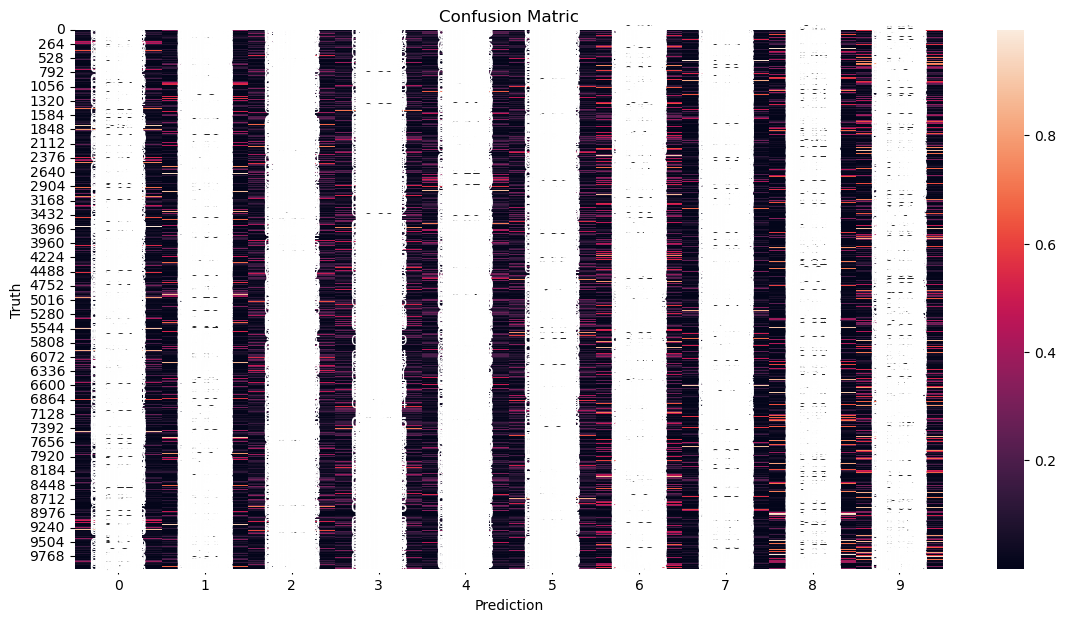

In [17]:
plt.figure(figsize = (14,7)) # Creates a larger canvas — 14 wide, 7 tall — for the heatmap
sns.heatmap(y_pred, annot = True) # annot=True would show numbers in each cell (slow for large data)
plt.ylabel('Truth') # Labels the vertical axis as 'Truth' (actual correct labels)
plt.xlabel('Prediction') # Labels the horizontal axis as 'Prediction' (what model predicted)
plt.title('Confusion Matric')
plt.show

In [18]:
cnn = models.Sequential([    # Sequential model — layers stacked in order
    layers.Input(shape=(32, 32, 3)),   # tells the layer the image dimensions
    layers.Conv2D(filters= 32, kernel_size= (3, 3), activation= 'relu'), # filters=32 → 32 different feature detectors (each learns different pattern)
                                                                         # kernel_size=(3,3) → each detector is a 3x3 sliding window
    layers.MaxPooling2D((2, 4)),    # Shrinks the feature maps by taking the maximum value in each 2x4 block
                                    # Reduces spatial dimensions by half (32x32 becomes 16x8)
                                    # Keeps the most important features while reducing computation
                                    # Also helps reduce overfitting

    layers.Conv2D(filters= 64, kernel_size= (3, 3), activation= 'relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(), # Converts the 3D feature maps into a 1D array
                      # Unlike ANN's flatten, CNN's flatten comes AFTER feature extraction
                      # So spatial information was already captured by conv layers
    layers.Dense(64, activation= 'relu'),   # Fully connected layer with 64 neurons
                                            # Takes the flattened features and learns class relationships
                                            # Much smaller than ANN's dense layers because CNN already extracted features
    layers.Dense(10, activation= 'softmax') # softmax converts scores to probabilities that sum to 1.0
])

In [19]:
cnn.compile(optimizer='adam',   # Adam optimizer — smarter than SGD used in ANN
                                # Automatically adjusts learning rate during training
                                # Converges faster and more stably than SGD
    loss= 'sparse_categorical_crossentropy',
    metrics= ['accuracy'])

In [29]:
# Trains the CNN on all 50,000 training images
# epochs=10 → model sees all images 10 complete times
# More epochs than ANN because CNN has more to learn
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.4391 - loss: 1.5550
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 30s 19ms/step - accuracy: 0.5775 - loss: 1.1997
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.6225 - loss: 1.0778
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.6511 - loss: 1.0007
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.6716 - loss: 0.9479
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 19ms/step - accuracy: 0.6849 - loss: 0.9062
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.6979 - loss: 0.8667
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7076 - loss: 0.8381
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 31s 20ms/step - accuracy: 0.7181 - loss: 0.8085
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.7275 - loss: 0.7819


In [30]:
# Max_pooling - reduces image dimension while preserving features
# Returns [loss, accuracy]
# loss     → how wrong the predictions are on average (lower is better)
# accuracy → percentage of images correctly classified
cnn.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6784 - loss: 0.9516


[0.9515547752380371, 0.6783999800682068]

In [31]:
# Runs CNN on all 10,000 test images
# Returns probability arrays — shape (10000, 10)
# Each row has 10 probabilities, one per class
y_pred = cnn.predict(X_test) 
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


array([[9.7445375e-04, 1.2182444e-04, 3.0269029e-03, 8.5875893e-01,
        3.9350209e-04, 1.2909311e-01, 1.7817968e-03, 1.2370710e-03,
        4.5287502e-03, 8.3620187e-05],
       [2.1513440e-02, 1.3779582e-02, 6.8923309e-06, 3.6746690e-06,
        9.8873045e-07, 4.5716709e-07, 5.5586077e-07, 2.3887813e-07,
        9.6432096e-01, 3.7306044e-04],
       [5.3990865e-01, 1.2762312e-02, 1.1197622e-02, 5.9706173e-03,
        8.1680268e-03, 1.1140417e-03, 2.1559405e-04, 6.8490785e-03,
        3.8883045e-01, 2.4983572e-02],
       [8.3918875e-01, 1.7349112e-03, 2.6544682e-03, 1.0279606e-03,
        1.4910844e-02, 3.5566418e-04, 2.2229893e-04, 2.1884504e-03,
        1.3739720e-01, 3.1952671e-04],
       [6.8895071e-07, 2.5354984e-06, 2.7317220e-02, 1.7122466e-02,
        5.0977820e-01, 7.0239911e-03, 4.3871820e-01, 3.4652665e-05,
        1.6662028e-06, 3.6127005e-07]], dtype=float32)

In [32]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[3, 8, 0, 0, 4]

In [33]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

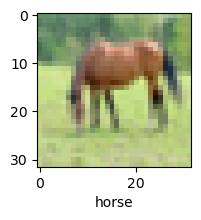

In [34]:
plot_sample(X_test, y_test, 60)

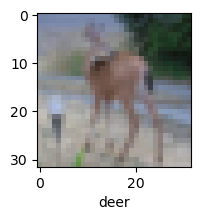

In [35]:
plot_sample(X_test, y_test, 100)

In [36]:
classes[y_classes[60]]

'horse'

In [37]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Enhancement 3: Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,       # Rotate image
    width_shift_range=0.1,   # Horizontal shift
    height_shift_range=0.1,  # Vertical shift
    horizontal_flip=True,    # Flip image
    zoom_range=0.1           # Zoom in/out
)

In [38]:
from tensorflow.keras import models, layers

new_cnn = models.Sequential([

    # Input Layer
    layers.Input(shape=(32, 32, 3)),

    # ==================================
    # Block 1
    # ==================================
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    # Enhancement 2
    layers.Dropout(0.25),

    # ==================================
    # Block 2
    # ==================================
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    # Enhancement 2
    layers.Dropout(0.25),

    # ==================================
    # Block 3
    # Enhancement 1
    # ==================================
    layers.Conv2D( 128,  (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),

    # Enhancement 2
    layers.Dropout(0.25),
    layers.Flatten(),
    layers.Dense( 128, activation='relu' ),

    # Enhancement 2
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(10, activation='softmax')
])

In [39]:
new_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [40]:
history = new_cnn.fit(
    datagen.flow(
        X_train,
        y_train,
        batch_size=64
    ),
    epochs=10,
    validation_data=(X_test, y_test)
)

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 165s 201ms/step - accuracy: 0.3235 - loss: 1.8128 - val_accuracy: 0.4960 - val_loss: 1.4422
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 144s 185ms/step - accuracy: 0.4679 - loss: 1.4635 - val_accuracy: 0.5541 - val_loss: 1.2295
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 148s 189ms/step - accuracy: 0.5255 - loss: 1.3253 - val_accuracy: 0.6111 - val_loss: 1.0852
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 150s 192ms/step - accuracy: 0.5576 - loss: 1.2399 - val_accuracy: 0.6217 - val_loss: 1.0529
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 147s 188ms/step - accuracy: 0.5878 - loss: 1.1722 - val_accuracy: 0.6528 - val_loss: 0.9624
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 148s 188ms/step - accuracy: 0.6045 - loss: 1.1229 - val_accuracy: 0.6756 - val_loss: 0.9065
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 146s 186ms/step - accuracy: 0.6216 - loss: 1.0798 - val_accuracy: 0.6666 - val_loss: 0.9519
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 151s 193ms/step - accuracy: 0.6332 -

In [41]:
new_loss, new_accuracy = new_cnn.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("===== New_CNN Evaluation =====")
print(f"Accuracy: {new_accuracy*100:.2f}%")
print(f"Loss: {new_loss:.4f}")

===== New_CNN Evaluation =====
Accuracy: 71.91%
Loss: 0.7985


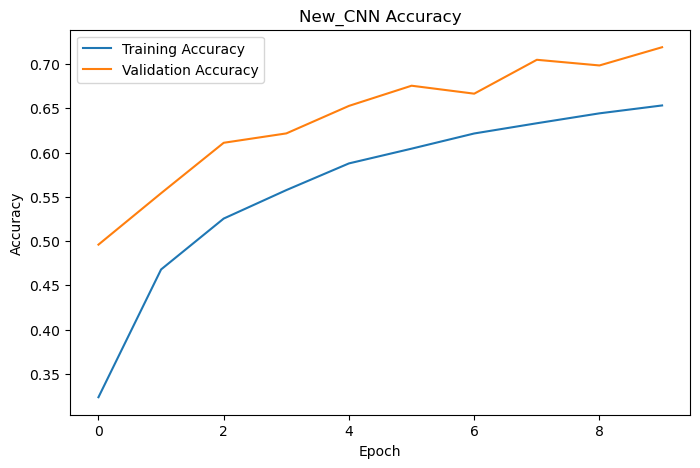

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('New_CNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

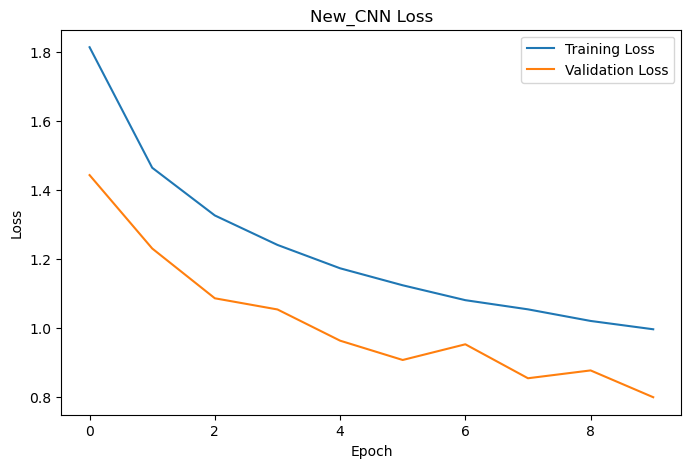

In [43]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('New_CNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 32ms/step


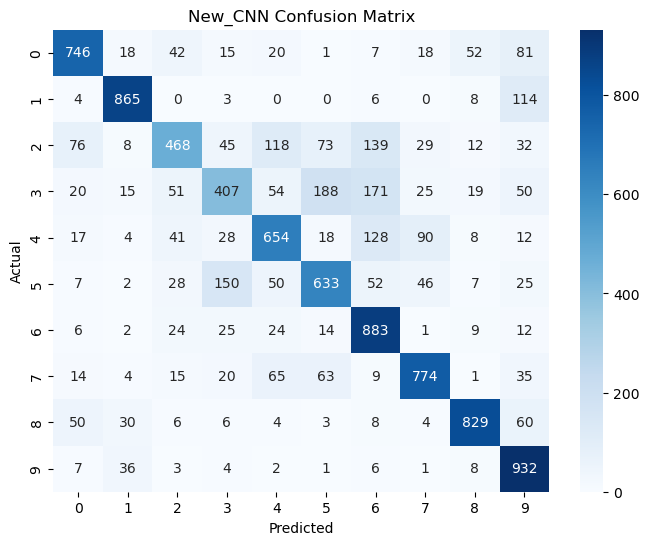

In [44]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = new_cnn.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix( y_test, y_pred_classes)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title('New_CNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()